<a href="https://colab.research.google.com/github/Sampaioooo/fake-news-bertimbau-tde/blob/main/notebooks/fake_news_bertimbau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install -U "transformers>=4.44.0" "datasets==3.6.0" "accelerate>=0.33.0" evaluate scikit-learn matplotlib
!pip -q install "pandas==2.2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 60.8 MB/s eta 0:00:00


In [2]:
import pandas as pd

print(pd.__version__)

2.2.2


In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo usado:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Atenção: a GPU não está ativa. O treinamento pode ficar lento.")

Dispositivo usado: cuda
GPU: Tesla T4


In [5]:
dataset = load_dataset(
    "fake-news-UFG/fakebr",
    "full_texts",
    trust_remote_code=True
)

dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

fakebr.py:   0%|          | 0.00/7.48k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'author', 'link', 'category', 'date of publication', 'number of tokens', 'number of words without punctuation', 'number of types', 'number of links inside the news', 'number of words in upper case', 'number of verbs', 'number of subjuntive and imperative verbs', 'number of nouns', 'number of adjectives', 'number of adverbs', 'number of modal verbs (mainly auxiliary verbs)', 'number of singular first and second personal pronouns', 'number of plural first personal pronouns', 'number of pronouns', 'pausality', 'number of characters', 'average sentence length', 'average word length', 'percentage of news with speeling errors', 'emotiveness', 'diversity'],
        num_rows: 7200
    })
})

In [6]:
dados = dataset["train"]

print("Quantidade total de notícias:", len(dados))
print("Colunas disponíveis:", dados.column_names)
print("Classes:", dados.features["label"].names)

exemplo = dados[0]

print("\nClasse do primeiro exemplo:", dados.features["label"].int2str(exemplo["label"]))
print("\nTexto do primeiro exemplo:")
print(exemplo["text"][:1000])

Quantidade total de notícias: 7200
Colunas disponíveis: ['text', 'label', 'author', 'link', 'category', 'date of publication', 'number of tokens', 'number of words without punctuation', 'number of types', 'number of links inside the news', 'number of words in upper case', 'number of verbs', 'number of subjuntive and imperative verbs', 'number of nouns', 'number of adjectives', 'number of adverbs', 'number of modal verbs (mainly auxiliary verbs)', 'number of singular first and second personal pronouns', 'number of plural first personal pronouns', 'number of pronouns', 'pausality', 'number of characters', 'average sentence length', 'average word length', 'percentage of news with speeling errors', 'emotiveness', 'diversity']
Classes: ['fake', 'true']

Classe do primeiro exemplo: fake

Texto do primeiro exemplo:
Juiz Sérgio Moro divulga nota contra a ANISTIA DO CAIXA 2. Temos que pressionar os deputados urgentemente!.  O juiz federal Sérgio Moro divulgou uma nota analisando o risco da apro

In [7]:
dados_limpos = dados.select_columns(["text", "label"])

print(dados_limpos)
print("Classes:", dados_limpos.features["label"].names)
print("Exemplo:", dados_limpos[0])

Dataset({
    features: ['text', 'label'],
    num_rows: 7200
})
Classes: ['fake', 'true']
Exemplo: {'text': 'Juiz Sérgio Moro divulga nota contra a ANISTIA DO CAIXA 2. Temos que pressionar os deputados urgentemente!.  O juiz federal Sérgio Moro divulgou uma nota analisando o risco da aprovação da anista do Caixa 2.  *** leia-se por anistia de caixa2 PERDÃO PARA CRIMINOSOS *** Moro fez questão de ressaltar que "anistiar as condutas de corrupção e de lavagem impactaria não só as investigações e os processos já julgados no âmbito da Operação Lava jato,  como também a integridade e a credibilidade do Estado de Direito e da democracia brasileira" Caro leitor,  dá pra entender a gravidade desse fato? Provavelmente,  aqueles que já estão presos em Curitiba,  serão soltos e ganharão "perdão da lei". É isso mesmo [...] presos como José Dirceu e CIA. poderão "até" ser soltos! abaixo a nota do juiz:', 'label': 0}


In [9]:
from datasets import config

config.TORCHVISION_AVAILABLE = False

print("Torchvision desativado para evitar conflito com datasets.")

Torchvision desativado para evitar conflito com datasets.


In [10]:
divisao_inicial = dados_limpos.train_test_split(
    test_size=0.30,
    seed=42,
    stratify_by_column="label"
)

divisao_validacao_teste = divisao_inicial["test"].train_test_split(
    test_size=0.50,
    seed=42,
    stratify_by_column="label"
)

dataset_final = DatasetDict({
    "train": divisao_inicial["train"],
    "validation": divisao_validacao_teste["train"],
    "test": divisao_validacao_teste["test"]
})

dataset_final

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 5040
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1080
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1080
    })
})

In [11]:
for parte in dataset_final:
    labels = dataset_final[parte]["label"]
    contagem = pd.Series(labels).value_counts().sort_index()

    print(f"\n{parte.upper()}")
    for indice, quantidade in contagem.items():
        nome_classe = dados_limpos.features["label"].int2str(indice)
        print(f"{nome_classe}: {quantidade}")


TRAIN
fake: 2520
true: 2520

VALIDATION
fake: 540
true: 540

TEST
fake: 540
true: 540


In [12]:
modelo_base = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(modelo_base)

print("Tokenizer carregado:", modelo_base)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer carregado: neuralmind/bert-base-portuguese-cased


In [13]:
def tokenizar(exemplos):
    return tokenizer(
        exemplos["text"],
        truncation=True,
        max_length=256
    )

dataset_tokenizado = dataset_final.map(
    tokenizar,
    batched=True,
    remove_columns=["text"]
)

dataset_tokenizado

Map:   0%|          | 0/5040 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5040
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1080
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1080
    })
})

In [16]:
id2label = {
    0: "fake",
    1: "true"
}

label2id = {
    "fake": 0,
    "true": 1
}

modelo = AutoModelForSequenceClassification.from_pretrained(
    modelo_base,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def calcular_metricas(pred):
    logits, labels = pred
    predicoes = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predicoes)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predicoes,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Modelo carregado com sucesso.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

Modelo carregado com sucesso.


In [18]:
argumentos_treinamento = TrainingArguments(
    output_dir="./resultados_bertimbau_fake_news",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none"
)

try:
    trainer = Trainer(
        model=modelo,
        args=argumentos_treinamento,
        train_dataset=dataset_tokenizado["train"],
        eval_dataset=dataset_tokenizado["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=calcular_metricas
    )

except TypeError:
    trainer = Trainer(
        model=modelo,
        args=argumentos_treinamento,
        train_dataset=dataset_tokenizado["train"],
        eval_dataset=dataset_tokenizado["validation"],
        data_collator=data_collator,
        compute_metrics=calcular_metricas
    )

print("Treinamento configurado.")

Treinamento configurado.


In [19]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.087900,0.070393,0.985185,0.985512,0.985185,0.985183


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.087900,0.070393,0.985185,0.985512,0.985185,0.985183
2,0.010421,0.013192,0.996296,0.996296,0.996296,0.996296


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1260, training_loss=0.06374719951187245, metrics={'train_runtime': 627.4553, 'train_samples_per_second': 16.065, 'train_steps_per_second': 2.008, 'total_flos': 1326079719014400.0, 'train_loss': 0.06374719951187245, 'epoch': 2.0})

In [20]:
resultado_teste = trainer.evaluate(dataset_tokenizado["test"])

resultado_teste

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.010421,0.011028,2,0.996296,0.996296,0.996296,0.996296


{'eval_loss': 0.011027763597667217,
 'eval_accuracy': 0.9962962962962963,
 'eval_precision': 0.9962962962962963,
 'eval_recall': 0.9962962962962963,
 'eval_f1': 0.9962962962962963}

In [21]:
predicoes = trainer.predict(dataset_tokenizado["test"])

y_real = predicoes.label_ids
y_pred = np.argmax(predicoes.predictions, axis=1)

nomes_classes = ["fake", "true"]

print(classification_report(
    y_real,
    y_pred,
    target_names=nomes_classes,
    digits=4
))

              precision    recall  f1-score   support

        fake     0.9963    0.9963    0.9963       540
        true     0.9963    0.9963    0.9963       540

    accuracy                         0.9963      1080
   macro avg     0.9963    0.9963    0.9963      1080
weighted avg     0.9963    0.9963    0.9963      1080



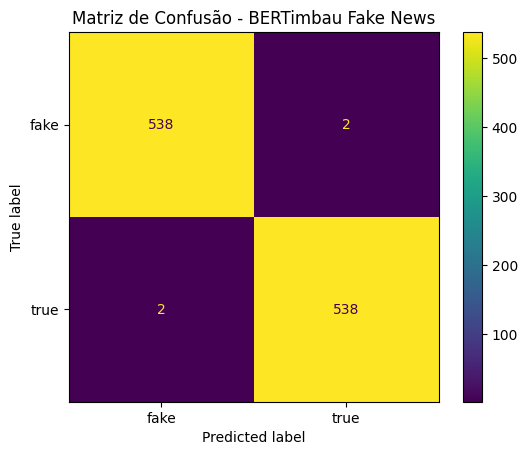

In [22]:
matriz = confusion_matrix(y_real, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=nomes_classes
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - BERTimbau Fake News")
plt.show()

In [23]:
def prever_noticia(texto):
    entradas = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    entradas = {chave: valor.to(modelo.device) for chave, valor in entradas.items()}

    with torch.no_grad():
        saida = modelo(**entradas)
        probabilidades = torch.softmax(saida.logits, dim=1)
        classe_prevista = torch.argmax(probabilidades, dim=1).item()

    return {
        "classe": id2label[classe_prevista],
        "probabilidade_fake": float(probabilidades[0][0]),
        "probabilidade_true": float(probabilidades[0][1])
    }

texto_teste_1 = "Pesquisadores anunciam nova tecnologia para melhorar a detecção de doenças em exames médicos."
texto_teste_2 = "Urgente! Governo confirma que todos os bancos vão bloquear contas amanhã sem aviso."

print(prever_noticia(texto_teste_1))
print(prever_noticia(texto_teste_2))

{'classe': 'fake', 'probabilidade_fake': 0.9946243166923523, 'probabilidade_true': 0.005375624634325504}
{'classe': 'fake', 'probabilidade_fake': 0.9998018145561218, 'probabilidade_true': 0.00019819554290734231}


In [24]:
import os

os.makedirs("resultados", exist_ok=True)
os.makedirs("modelo_treinado", exist_ok=True)

print("Pastas criadas com sucesso.")

Pastas criadas com sucesso.


In [25]:
metricas_teste = {
    "accuracy": resultado_teste.get("eval_accuracy"),
    "precision": resultado_teste.get("eval_precision"),
    "recall": resultado_teste.get("eval_recall"),
    "f1": resultado_teste.get("eval_f1"),
    "loss": resultado_teste.get("eval_loss")
}

df_metricas = pd.DataFrame([metricas_teste])

df_metricas.to_csv("resultados/metricas_teste.csv", index=False)

df_metricas

,accuracy,precision,recall,f1,loss
0,0.996296,0.996296,0.996296,0.996296,0.011028


In [26]:
relatorio_dict = classification_report(
    y_real,
    y_pred,
    target_names=nomes_classes,
    digits=4,
    output_dict=True
)

df_relatorio = pd.DataFrame(relatorio_dict).transpose()

df_relatorio.to_csv("resultados/relatorio_classificacao.csv")

df_relatorio

,precision,recall,f1-score,support
fake,0.996296,0.996296,0.996296,540.000000
true,0.996296,0.996296,0.996296,540.000000
accuracy,0.996296,0.996296,0.996296,0.996296
macro avg,0.996296,0.996296,0.996296,1080.000000
weighted avg,0.996296,0.996296,0.996296,1080.000000


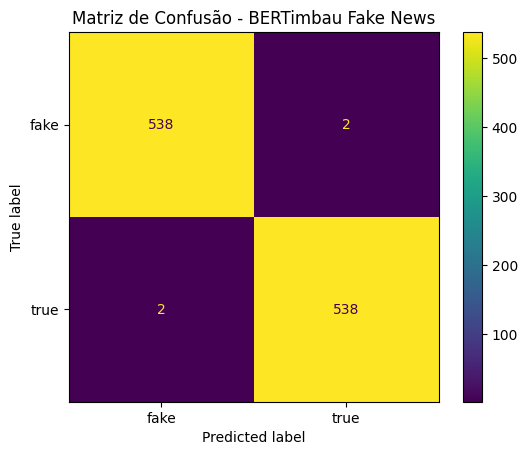

Matriz de confusão salva em: resultados/matriz_confusao.png


In [27]:
matriz = confusion_matrix(y_real, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=nomes_classes
)

disp.plot(values_format="d")
plt.title("Matriz de Confusão - BERTimbau Fake News")
plt.savefig("resultados/matriz_confusao.png", dpi=300, bbox_inches="tight")
plt.show()

print("Matriz de confusão salva em: resultados/matriz_confusao.png")

In [28]:
modelo.save_pretrained("modelo_treinado")
tokenizer.save_pretrained("modelo_treinado")

print("Modelo e tokenizer salvos na pasta modelo_treinado.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo e tokenizer salvos na pasta modelo_treinado.


In [29]:
textos_teste = [
    "Pesquisadores anunciam nova tecnologia para melhorar a detecção de doenças em exames médicos.",
    "Urgente! Governo confirma que todos os bancos vão bloquear contas amanhã sem aviso.",
    "Universidade divulga calendário acadêmico atualizado para o próximo semestre.",
    "Cientistas revelam que beber água com limão cura todas as doenças em 24 horas."
]

resultados_manuais = []

for texto in textos_teste:
    resultado = prever_noticia(texto)

    resultados_manuais.append({
        "texto": texto,
        "classe_prevista": resultado["classe"],
        "probabilidade_fake": resultado["probabilidade_fake"],
        "probabilidade_true": resultado["probabilidade_true"]
    })

df_testes_manuais = pd.DataFrame(resultados_manuais)

df_testes_manuais.to_csv("resultados/testes_manuais.csv", index=False)

df_testes_manuais

,texto,classe_prevista,probabilidade_fake,probabilidade_true
0,Pesquisadores anunciam nova tecnologia para me...,fake,0.994624,0.005376
1,Urgente! Governo confirma que todos os bancos ...,fake,0.999802,0.000198
2,Universidade divulga calendário acadêmico atua...,fake,0.853185,0.146815
3,Cientistas revelam que beber água com limão cu...,fake,0.984996,0.015004


In [30]:
!zip -r resultados_projeto_fake_news.zip resultados modelo_treinado

  adding: resultados/ (stored 0%)
  adding: resultados/testes_manuais.csv (deflated 33%)
  adding: resultados/relatorio_classificacao.csv (deflated 74%)
  adding: resultados/matriz_confusao.png (deflated 20%)
  adding: resultados/metricas_teste.csv (deflated 50%)
  adding: modelo_treinado/ (stored 0%)
  adding: modelo_treinado/tokenizer.json (deflated 72%)
  adding: modelo_treinado/model.safetensors (deflated 7%)
  adding: modelo_treinado/config.json (deflated 56%)
  adding: modelo_treinado/tokenizer_config.json (deflated 43%)


In [31]:
print("CONCLUSÃO TÉCNICA DO EXPERIMENTO")
print("-" * 50)
print("O modelo BERTimbau foi ajustado para classificar notícias em português como fake ou true.")
print("A base Fake.Br foi utilizada por conter notícias falsas e verdadeiras em português brasileiro.")
print("No conjunto de teste, o modelo alcançou aproximadamente 99,63% de acurácia, precisão, recall e F1-score.")
print("A matriz de confusão indicou apenas 4 erros em 1080 exemplos testados.")
print("Apesar do bom desempenho, os testes manuais com frases curtas mostraram que o modelo pode ter dificuldade fora do padrão da base original.")
print("Portanto, o modelo apresenta bom desempenho experimental, mas ainda precisaria de validação com novos dados antes de uso em ambiente real.")

CONCLUSÃO TÉCNICA DO EXPERIMENTO
--------------------------------------------------
O modelo BERTimbau foi ajustado para classificar notícias em português como fake ou true.
A base Fake.Br foi utilizada por conter notícias falsas e verdadeiras em português brasileiro.
No conjunto de teste, o modelo alcançou aproximadamente 99,63% de acurácia, precisão, recall e F1-score.
A matriz de confusão indicou apenas 4 erros em 1080 exemplos testados.
Apesar do bom desempenho, os testes manuais com frases curtas mostraram que o modelo pode ter dificuldade fora do padrão da base original.
Portanto, o modelo apresenta bom desempenho experimental, mas ainda precisaria de validação com novos dados antes de uso em ambiente real.
